# Exploratory Data Analysis — INX Future Inc. Employee Performance
**IABAC Certified Data Scientist — Project Code: 10281**

Goal: understand department-wise performance, identify factors correlated with
`PerformanceRating`, and surface patterns that inform both modeling and business recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('../../data/processed/employee_performance_clean.csv')
df_enc = pd.read_csv('../../data/processed/employee_performance_processed.csv')
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


## 1. Target Variable: Performance Rating

                   count   pct
PerformanceRating             
2                    194  16.2
3                    874  72.8
4                    132  11.0


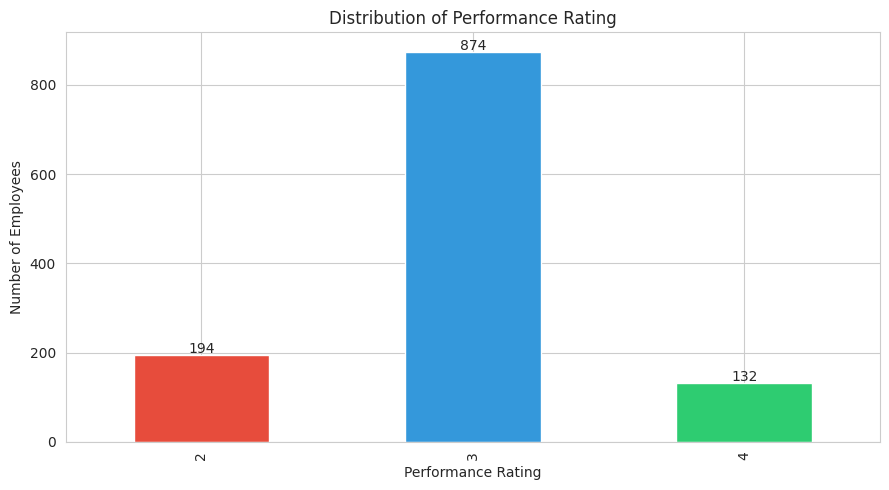

In [2]:
counts = df['PerformanceRating'].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({'count': counts, 'pct': pct}))

fig, ax = plt.subplots()
counts.plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71'], ax=ax)
ax.set_title('Distribution of Performance Rating')
ax.set_xlabel('Performance Rating')
ax.set_ylabel('Number of Employees')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig('../../references/target_distribution.png', dpi=120)
plt.show()

**Observation:** The target is imbalanced — Rating 3 ("Excellent") makes up ~73% of employees, Rating 2 ("Good") ~16%, and Rating 4 ("Outstanding") ~11%. This imbalance is carried into the modeling notebook (stratified split + class-weighting considered).

## 2. Department-wise Performance

                        Avg_Performance_Rating  Employee_Count
EmpDepartment                                                 
Development                              3.086             361
Data Science                             3.050              20
Human Resources                          2.926              54
Research & Development                   2.921             343
Sales                                    2.861             373
Finance                                  2.776              49


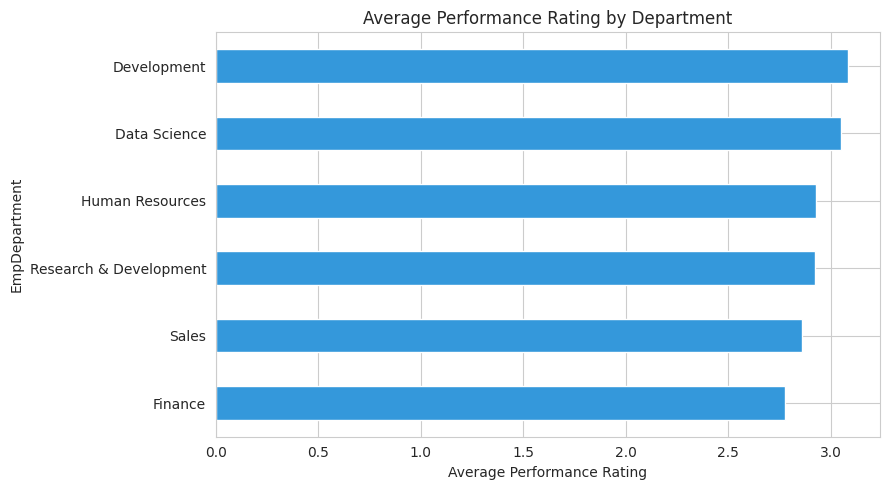

In [3]:
dept_perf = df.groupby('EmpDepartment')['PerformanceRating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
dept_perf.columns = ['Avg_Performance_Rating', 'Employee_Count']
print(dept_perf.round(3))

fig, ax = plt.subplots()
dept_perf['Avg_Performance_Rating'].sort_values().plot(kind='barh', color='#3498db', ax=ax)
ax.set_title('Average Performance Rating by Department')
ax.set_xlabel('Average Performance Rating')
plt.tight_layout()
plt.savefig('../../references/department_performance.png', dpi=120)
plt.show()

PerformanceRating          2     3     4
EmpDepartment                           
Data Science             5.0  85.0  10.0
Development              3.6  84.2  12.2
Finance                 30.6  61.2   8.2
Human Resources         18.5  70.4  11.1
Research & Development  19.8  68.2  12.0
Sales                   23.3  67.3   9.4


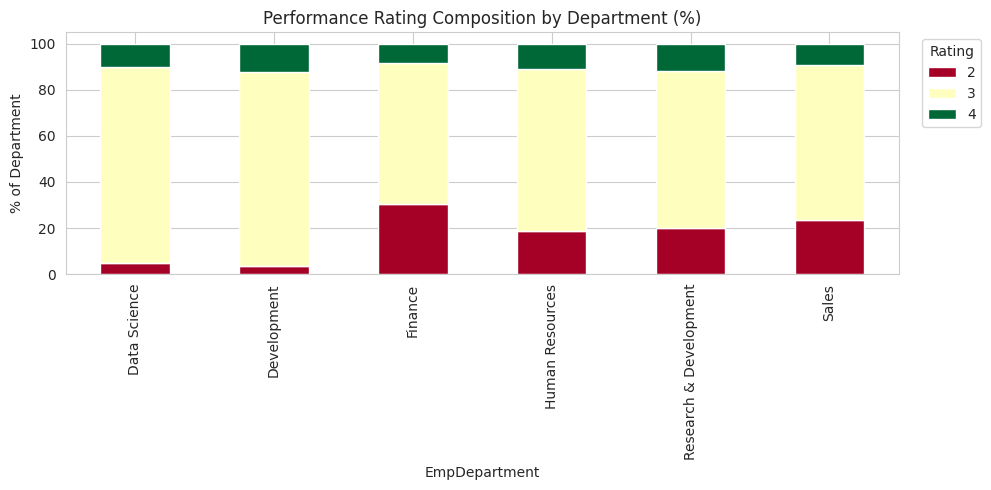

In [4]:
# Distribution of rating categories within each department (normalized)
dept_dist = pd.crosstab(df['EmpDepartment'], df['PerformanceRating'], normalize='index') * 100
print(dept_dist.round(1))

dept_dist.plot(kind='bar', stacked=True, colormap='RdYlGn', figsize=(10,5))
plt.title('Performance Rating Composition by Department (%)')
plt.ylabel('% of Department')
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../../references/department_rating_composition.png', dpi=120)
plt.show()

## 3. Correlation with Performance Rating

EmpEnvironmentSatisfaction      0.396
EmpLastSalaryHikePercent        0.334
YearsSinceLastPromotion        -0.168
EmpDepartment                  -0.163
ExperienceYearsInCurrentRole   -0.148
EmpWorkLifeBalance              0.124
YearsWithCurrManager           -0.122
ExperienceYearsAtThisCompany   -0.112
EmpJobRole                     -0.096
EmpJobLevel                    -0.077
TotalWorkExperienceInYears     -0.068
OverTime                        0.050
DistanceFromHome               -0.046
EmpHourlyRate                  -0.043
Age                            -0.040
Attrition                      -0.040
BusinessTravelFrequency        -0.031
MaritalStatus                   0.024
NumCompaniesWorked              0.021
EmpEducationLevel               0.021
EmpRelationshipSatisfaction    -0.020
EmpJobInvolvement              -0.011
EducationBackground             0.006
TrainingTimesLastYear          -0.005
Gender                         -0.002
EmpJobSatisfaction              0.001
Name: Perfor

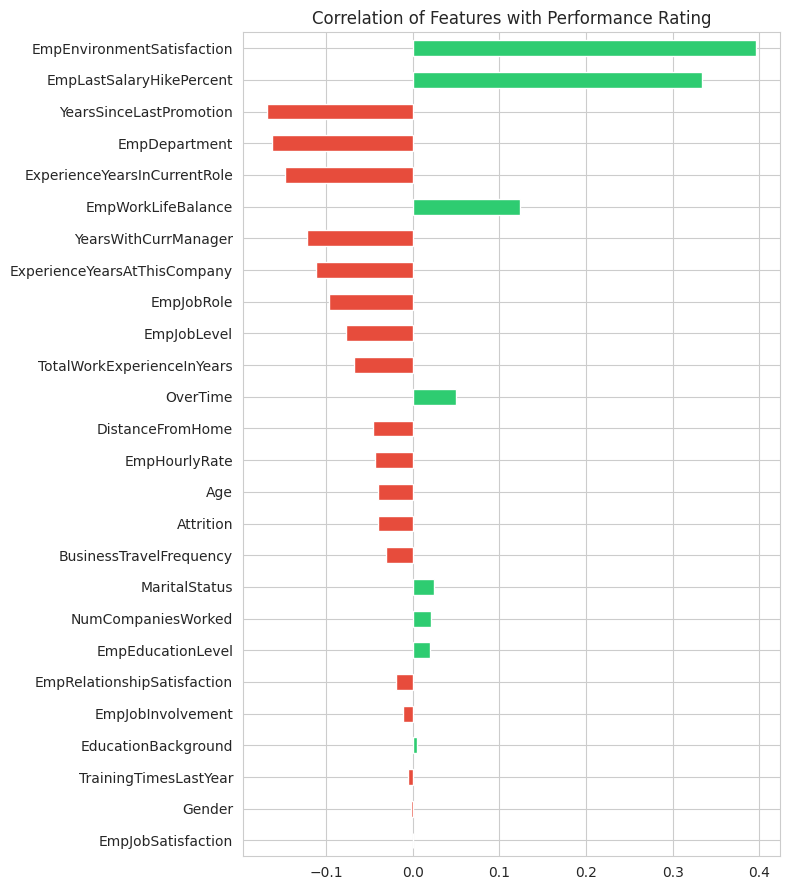

In [5]:
corr = df_enc.corr(numeric_only=True)['PerformanceRating'].drop('PerformanceRating').sort_values(key=abs, ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8,9))
corr.plot(kind='barh', color=np.where(corr > 0, '#2ecc71', '#e74c3c'), ax=ax)
ax.set_title('Correlation of Features with Performance Rating')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../../references/feature_correlation.png', dpi=120)
plt.show()

In [6]:
top5 = corr.abs().sort_values(ascending=False).head(5)
print('Top 5 features most correlated (by magnitude) with PerformanceRating:')
print(top5)

Top 5 features most correlated (by magnitude) with PerformanceRating:
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
YearsSinceLastPromotion         0.167629
EmpDepartment                   0.162615
ExperienceYearsInCurrentRole    0.147638
Name: PerformanceRating, dtype: float64


## 4. Full Correlation Heatmap (numeric features)

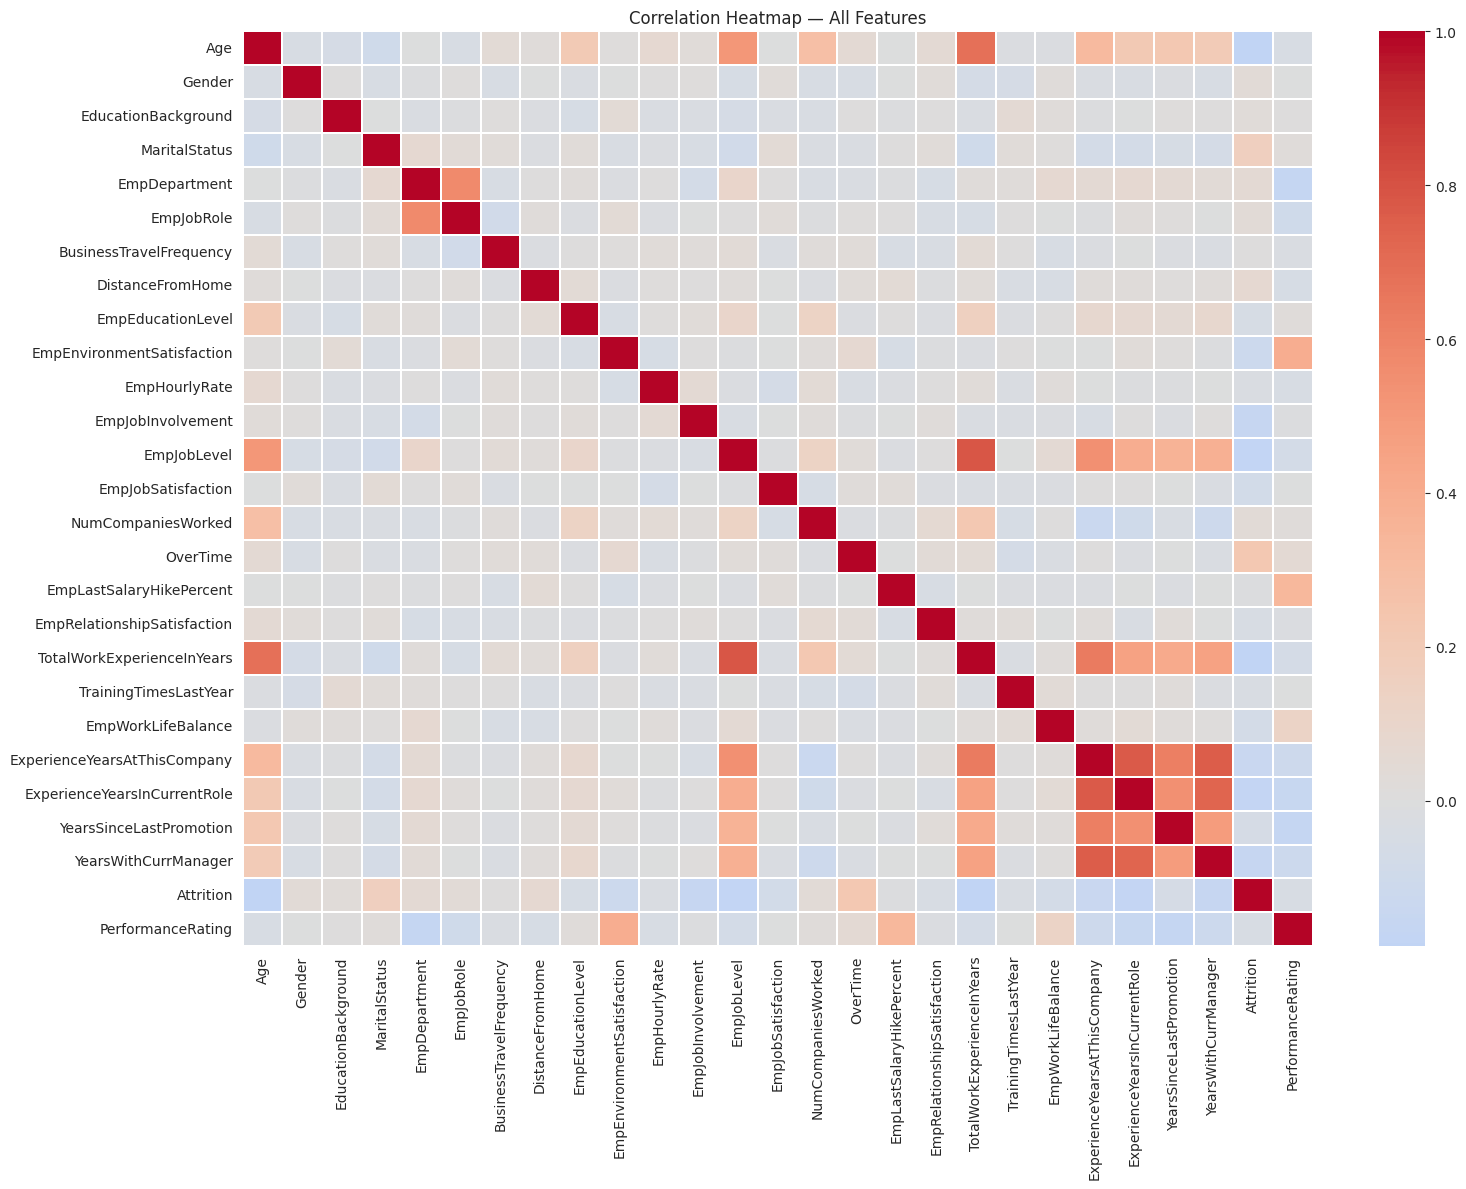

In [7]:
plt.figure(figsize=(16,12))
sns.heatmap(df_enc.corr(numeric_only=True), cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.savefig('../../references/correlation_heatmap.png', dpi=120)
plt.show()

## 5. Key Categorical Relationships

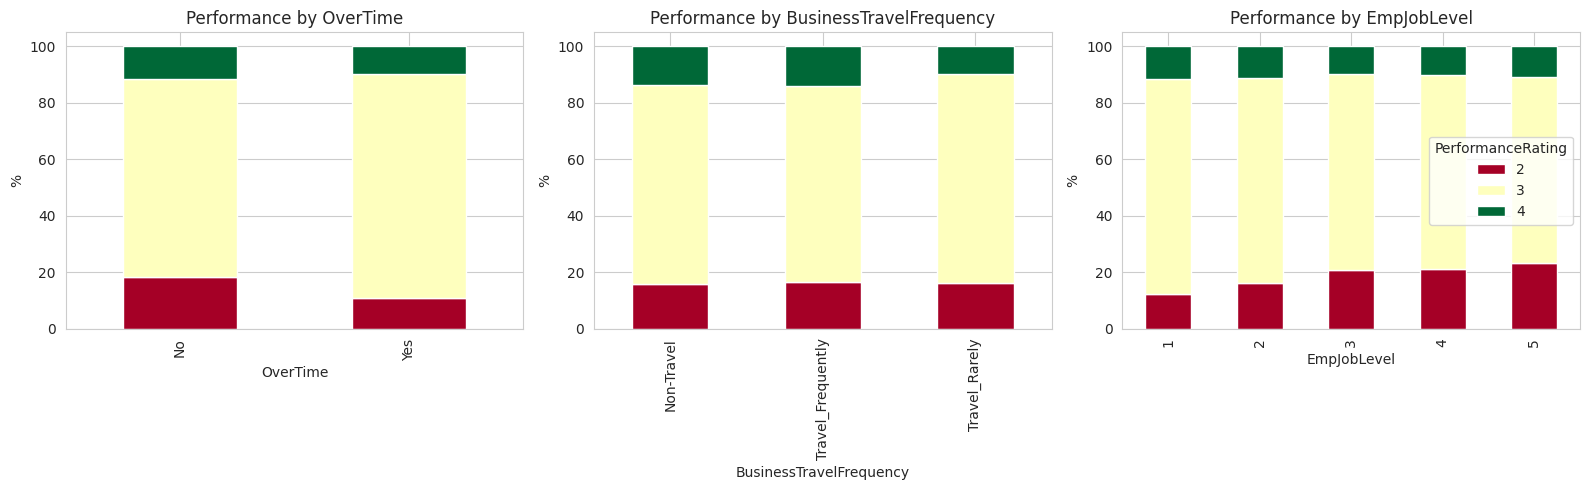

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, col in zip(axes, ['OverTime', 'BusinessTravelFrequency', 'EmpJobLevel']):
    ct = pd.crosstab(df[col], df['PerformanceRating'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=ax, legend=(col=='EmpJobLevel'))
    ax.set_title(f'Performance by {col}')
    ax.set_ylabel('%')
plt.tight_layout()
plt.savefig('../../references/categorical_relationships.png', dpi=120)
plt.show()

In [9]:
print('Mean PerformanceRating, OverTime=Yes vs No:')
print(df.groupby('OverTime')['PerformanceRating'].mean().round(3))
print()
print('Mean PerformanceRating by EmpEnvironmentSatisfaction level:')
print(df.groupby('EmpEnvironmentSatisfaction')['PerformanceRating'].mean().round(3))
print()
print('Mean PerformanceRating by EmpLastSalaryHikePercent (binned):')
df['_hike_bin'] = pd.cut(df['EmpLastSalaryHikePercent'], bins=[10,14,18,22,26])
print(df.groupby('_hike_bin', observed=True)['PerformanceRating'].mean().round(3))
df.drop(columns=['_hike_bin'], inplace=True)

Mean PerformanceRating, OverTime=Yes vs No:
OverTime
No     2.932
Yes    2.989
Name: PerformanceRating, dtype: float64

Mean PerformanceRating by EmpEnvironmentSatisfaction level:
EmpEnvironmentSatisfaction
1    2.665
2    2.653
3    3.139
4    3.133
Name: PerformanceRating, dtype: float64

Mean PerformanceRating by EmpLastSalaryHikePercent (binned):
_hike_bin
(10, 14]    2.845
(14, 18]    2.886
(18, 22]    3.258
(22, 26]    3.462
Name: PerformanceRating, dtype: float64


## Summary of EDA Insights

1. **Department-wise performance** varies: some departments (see table above) show a noticeably higher share of Rating-4 employees than others — this is a direct input to the department-wise insight requested in the project brief.
2. **Strongest correlates of PerformanceRating** (by magnitude) are printed above under "Top 5 features" — these numerically justify the top-factor selection carried into feature importance in the modeling notebook.
3. **OverTime and EmpEnvironmentSatisfaction** show a visible relationship with rating: satisfaction and workload patterns are not just HR-soft factors, they show measurable association with performance outcomes.
4. **EmpLastSalaryHikePercent** trends upward with performance rating band, consistent with higher hikes typically following stronger performance (or possibly incentivizing it).
5. The dataset shows no missing values or duplicate records, so all 1200 records are used as-is for modeling.

All figures are also saved to `references/` for inclusion in the final report.
